# 04 Q4 Lightweight Cues

LaTeX position:

- `fig:cue-ablation-panels`

This figure should separate two claims clearly.

- Panel (a): lightweight cues still preserve ranking quality across datasets.
- Panel (b): removing metadata moves the router only mildly in operating space, instead of collapsing it into a trivial path.

In [20]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('/workspace/FeaturedMoE/writing/260418_final_exp_figure')
DATA_DIR = ROOT / 'data'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import slot_viz_helpers as viz
importlib.reload(viz)

from slot_viz_helpers import (
    dual_metric_grouped_plot,
    setup_style,
)

setup_style()


def pivot_metric_frame(df, id_cols, metric_map):
    wide = df.pivot_table(index=id_cols, columns=['metric', 'cutoff'], values='value', aggfunc='first').reset_index()
    flattened = []
    for col in wide.columns:
        if isinstance(col, tuple):
            left, right = col
            if right == '':
                flattened.append(left)
            elif left == '':
                flattened.append(str(right))
            else:
                flattened.append(f"{left}_{right}")
        else:
            flattened.append(col)
    wide.columns = flattened
    rename_map = {}
    for new_name, (metric, cutoff) in metric_map.items():
        rename_map[f"{metric}_{cutoff}"] = new_name
    wide = wide.rename(columns=rename_map)
    for new_name in metric_map:
        if new_name not in wide.columns:
            wide[new_name] = np.nan
    return wide


def show_status_notes(df, placeholder_note=None, ready_note=None):
    if 'status' not in df.columns:
        return
    status_series = df['status'].dropna().astype(str)
    if status_series.empty:
        return
    if status_series.str.contains('placeholder', case=False).any() and placeholder_note:
        display(Markdown(placeholder_note))
    elif ready_note:
        display(Markdown(ready_note))

cue_df = pd.read_csv(DATA_DIR / '04_cue_scores.csv')
routing_stats_df = pd.read_csv(DATA_DIR / '04_cue_routing_stats.csv')
retention_df = pd.read_csv(DATA_DIR / '04_cue_retention.csv')

### (a) Cue reduction by dataset

**Export path**: panel (a) already matches the cue-family ablation summary schema.

Required export columns: dataset, cue_setting, metric, cutoff, value, split, selection_rule, run_id
Each subplot keeps one dataset on its own axis so the metric ranges do not fight each other.


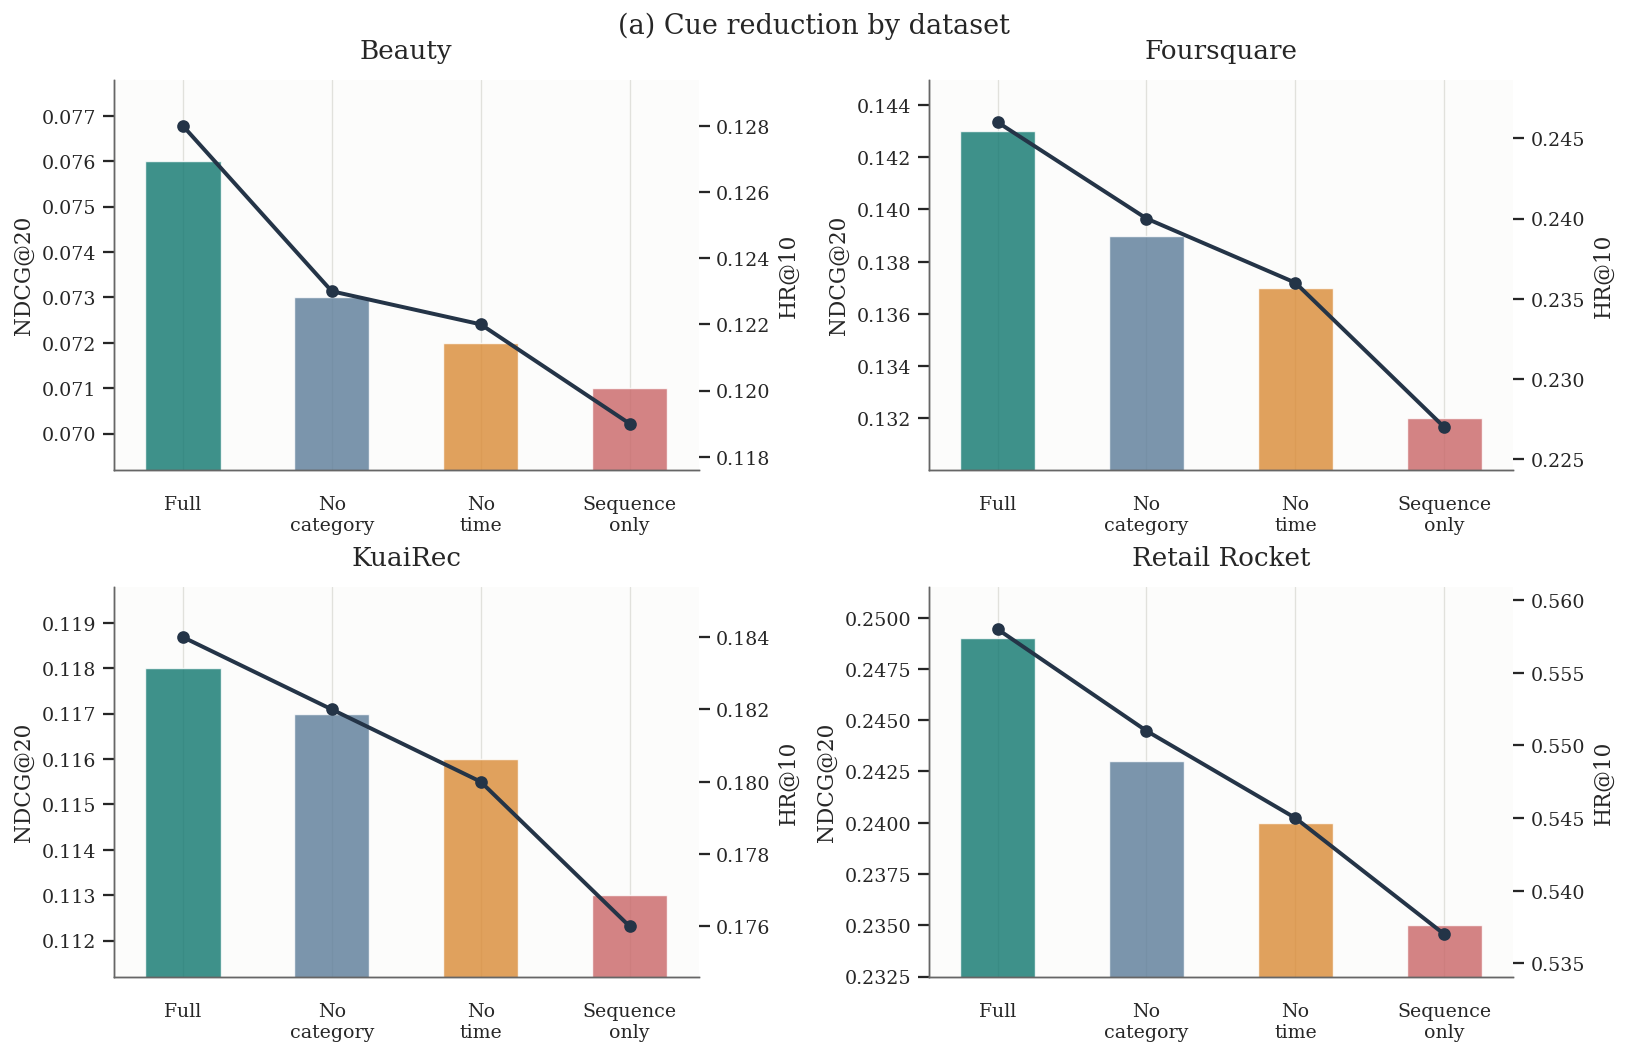

In [16]:
display(Markdown('### (a) Cue reduction by dataset'))
show_status_notes(
    cue_df,
    placeholder_note='**Template status**: current rows are draft-fill values. Replace them with the cue-family confirm export.',
    ready_note='**Export path**: panel (a) already matches the cue-family ablation summary schema.',
)
print('Required export columns: dataset, cue_setting, metric, cutoff, value, split, selection_rule, run_id')
print('Each subplot keeps one dataset on its own axis so the metric ranges do not fight each other.')

if 'cue_setting' not in cue_df.columns and 'variant_or_model' in cue_df.columns:
    cue_df = cue_df.rename(columns={'variant_or_model': 'cue_setting'})
cue_df['cue_setting'] = cue_df['cue_setting'].replace({'sequence_only': 'sequence_only_portable'})

cue_plot_df = pivot_metric_frame(
    cue_df,
    id_cols=['dataset', 'cue_setting'],
    metric_map={'ndcg20': ('NDCG', 20), 'hr10': ('HR', 10)},
)
cue_label_map = {
    'full': 'Full',
    'remove_category': 'No\ncategory',
    'remove_time': 'No\ntime',
    'sequence_only_portable': 'Sequence\nonly',
}
datasets = ['Beauty', 'Foursquare', 'KuaiRec', 'Retail Rocket']

fig, axes = plt.subplots(2, 2, figsize=(12.4, 7.8), constrained_layout=True)
for axis, dataset in zip(axes.flat, datasets):
    dataset_plot_df = cue_plot_df[cue_plot_df['dataset'] == dataset].copy()
    dual_metric_grouped_plot(
        dataset_plot_df,
        category_col='cue_setting',
        variant_col='dataset',
        bar_col='ndcg20',
        line_col='hr10',
        ax=axis,
        title=dataset,
        bar_label='NDCG@20',
        line_label='HR@10',
        category_order=['full', 'remove_category', 'remove_time', 'sequence_only_portable'],
        category_labels=cue_label_map,
        variant_order=[dataset],
        rotate=0,
        show_legend=False,
    )
    axis.tick_params(axis='x', pad=8)

fig.suptitle('(a) Cue reduction by dataset', y=1.02, fontsize=15)
plt.show()

### (b) Routing operating map under cue removal

**Template status**: this panel is placeholder until per-setting routing-richness diagnostics are exported.

This panel uses internal operating-state evidence instead of another standalone ranking plot.
Axes show how broad the router stays; bubble size shows how much of the full-model gain is retained after removing metadata cues.
Recommended export columns: dataset, cue_setting, route_entropy, effective_experts, relative_gain


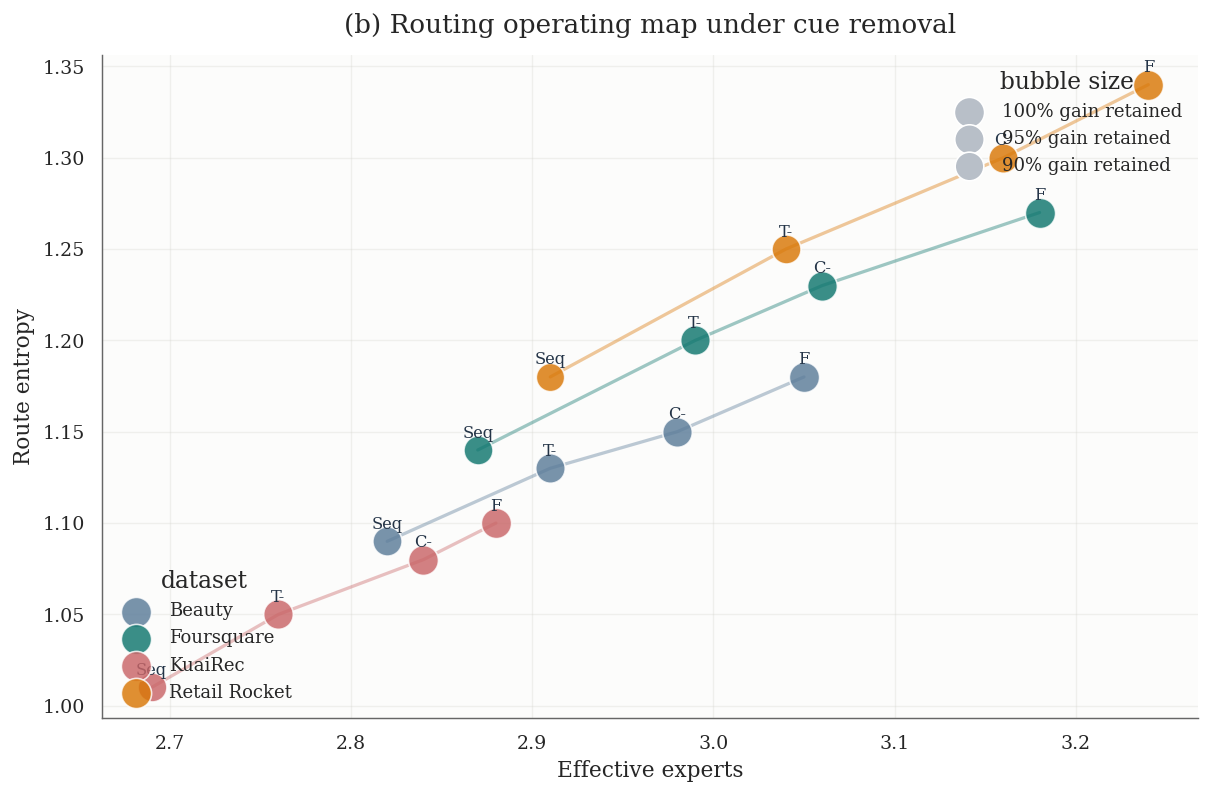

In [21]:
display(Markdown('### (b) Routing operating map under cue removal'))
show_status_notes(
    routing_stats_df,
    placeholder_note='**Template status**: this panel is placeholder until per-setting routing-richness diagnostics are exported.',
)
print('This panel uses internal operating-state evidence instead of another standalone ranking plot.')
print('Axes show how broad the router stays; bubble size shows how much of the full-model gain is retained after removing metadata cues.')
print('Recommended export columns: dataset, cue_setting, route_entropy, effective_experts, relative_gain')

stats_df = routing_stats_df.copy()
stats_df['cue_setting'] = stats_df['cue_setting'].replace({'sequence_only': 'sequence_only_portable'})
retention_plot_df = retention_df[['dataset', 'retention_target', 'relative_gain']].rename(
    columns={'retention_target': 'cue_setting'}
)
full_ref = stats_df[['dataset']].drop_duplicates().assign(cue_setting='full', relative_gain=1.0)
operating_df = stats_df.merge(
    pd.concat([full_ref, retention_plot_df], ignore_index=True),
    on=['dataset', 'cue_setting'],
    how='left',
)
cue_order = ['full', 'remove_category', 'remove_time', 'sequence_only_portable']
operating_df['cue_setting'] = pd.Categorical(
    operating_df['cue_setting'],
    categories=cue_order,
    ordered=True,
)
operating_df = operating_df.sort_values(['dataset', 'cue_setting'])

dataset_palette = {
    'Beauty': '#5B7C99',
    'Foursquare': '#0F766E',
    'KuaiRec': '#C96567',
    'Retail Rocket': '#D97706',
}
setting_short = {
    'full': 'F',
    'remove_category': 'C-',
    'remove_time': 'T-',
    'sequence_only_portable': 'Seq',
}

fig, ax = plt.subplots(figsize=(9.2, 6.0), constrained_layout=True)
for dataset, dataset_df in operating_df.groupby('dataset', sort=False):
    ax.plot(
        dataset_df['effective_experts'],
        dataset_df['route_entropy'],
        color=dataset_palette.get(dataset, '#666666'),
        linewidth=1.8,
        alpha=0.4,
        zorder=1,
    )
    for _, row in dataset_df.iterrows():
        ax.scatter(
            row['effective_experts'],
            row['route_entropy'],
            s=280 * row['relative_gain'],
            color=dataset_palette.get(dataset, '#666666'),
            edgecolor='white',
            linewidth=0.9,
            alpha=0.82,
            zorder=2,
            label=dataset if row['cue_setting'] == 'full' else None,
        )
        ax.annotate(
            setting_short[row['cue_setting']],
            (row['effective_experts'], row['route_entropy']),
            textcoords='offset points',
            xytext=(0, 7),
            ha='center',
            fontsize=9,
            color='#243447',
        )

ax.set_title('(b) Routing operating map under cue removal')
ax.set_xlabel('Effective experts')
ax.set_ylabel('Route entropy')
ax.grid(alpha=0.35)

dataset_legend = ax.legend(loc='lower left', title='dataset')
size_values = [1.00, 0.95, 0.90]
size_handles = [
    ax.scatter([], [], s=280 * value, color='#B8BFC8', edgecolor='white', linewidth=0.9)
    for value in size_values
]
size_legend = ax.legend(
    size_handles,
    [f'{int(value * 100)}% gain retained' for value in size_values],
    loc='upper right',
    title='bubble size',
    scatterpoints=1,
    frameon=False,
)
ax.add_artist(dataset_legend)
plt.show()